In [1]:
pip install pandas openpyxl matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# These are the only libraries you need for this project
import pandas as pd
import numpy as np
import os

In [2]:
# Load the raw CSV file
# low_memory=False prevents mixed-type warnings on large files
df = pd.read_csv('IPL.csv', low_memory=False)

# Check the shape — how many rows and columns
print("Shape:", df.shape)

# Check column names
print("\nColumns:\n", df.columns.tolist())

# Check data types of each column
print("\nData types:\n", df.dtypes)

# Check how many null values are in each column
print("\nNull counts:\n", df.isnull().sum())

# Preview first 3 rows
print("\nFirst 3 rows:\n", df.head(3))

Shape: (278205, 64)

Columns:
 ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']

Data types:
 Unnamed: 0           int64
match_id             int64
date                

In [3]:
# The first column has no name and has unreliable numbers
# We drop it using its position (column index 0)
df = df.drop(columns=[df.columns[0]])

print("Column dropped. New shape:", df.shape)


Column dropped. New shape: (278205, 63)


In [4]:
# Fix the date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Full list of columns that should be numeric
# These are the ORIGINAL names before any renaming
numeric_cols_original = [
    'over', 'ball', 'ball_no',
    'runs_batter', 'balls_faced', 'runs_extras',
    'runs_total', 'runs_bowler',
    'valid_ball', 'runs_target',
    'team_runs', 'team_balls', 'team_wicket', 'overs'
]

# Only keep the column names that actually exist in your dataframe
# This prevents the TypeError completely
existing_numeric_cols = [col for col in numeric_cols_original
                         if col in df.columns]

# Convert each existing column safely
for col in existing_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("Converted columns:", existing_numeric_cols)
print()
print("Data types after conversion:")
print(df[existing_numeric_cols].dtypes)

Converted columns: ['over', 'ball', 'ball_no', 'runs_batter', 'balls_faced', 'runs_extras', 'runs_total', 'runs_bowler', 'valid_ball', 'runs_target', 'team_runs', 'team_balls', 'team_wicket', 'overs']

Data types after conversion:
over             int64
ball             int64
ball_no        float64
runs_batter      int64
balls_faced      int64
runs_extras      int64
runs_total       int64
runs_bowler      int64
valid_ball       int64
runs_target    float64
team_runs        int64
team_balls       int64
team_wicket      int64
overs            int64
dtype: object


In [6]:
# Rename a few columns to make them clearer
df = df.rename(columns={
    'over'          : 'over_number',
    'runs_batter'   : 'batter_runs',
    'runs_total'    : 'total_runs',
    'runs_extras'   : 'extras',
    'runs_bowler'   : 'runs_conceded',
    'wicket_kind'   : 'dismissal_type',
    'player_out'    : 'dismissed_batter',
    'event_name'    : 'tournament',
})

print("Columns renamed successfully.")

Columns renamed successfully.


In [7]:
# For text columns where null means "nothing happened", fill with a label

# No extra was bowled — fill with "none"
df['extra_type'] = df['extra_type'].fillna('none')

# No wicket fell — batter is "not out"
df['dismissal_type'] = df['dismissal_type'].fillna('not_out')

# No batter was dismissed on this ball
df['dismissed_batter'] = df['dismissed_batter'].fillna('none')

# No fielder involved
df['fielders'] = df['fielders'].fillna('none')

# Match ended normally, not by Duckworth-Lewis
df['method'] = df['method'].fillna('normal')

# No super over was played
df['superover_winner'] = df['superover_winner'].fillna('none')

# Remove rows where critical columns are missing — these rows are unusable
df = df.dropna(subset=['match_id', 'batter', 'bowler'])

# Reset the row index after dropping rows
df = df.reset_index(drop=True)

print("Nulls filled. Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulls filled. Remaining nulls:
review_batter      277333
team_reviewed      277333
review_decision    277333
umpire             277333
win_outcome          4702
result_type        273503
new_batter         264884
next_batter        264884
dtype: int64


In [8]:
# 1. Create a unique delivery_id as the primary key
#    This gives every ball a clean, reliable unique number
df.insert(0, 'delivery_id', range(1, len(df) + 1))


In [9]:
print(df.columns[df.columns == 'batter_runs'])

Index(['batter_runs', 'batter_runs'], dtype='object')


In [10]:
df = df.loc[:, ~df.columns.duplicated()]

In [11]:
duplicates = df.columns[df.columns.duplicated()]
print("Duplicate columns:", duplicates)

Duplicate columns: Index([], dtype='object')


In [12]:
# 2. Boundary flags — 1 means yes, 0 means no
df['is_four']     = (df['batter_runs'] == 4).astype(int)
df['is_six']      = (df['batter_runs'] == 6).astype(int)
df['is_boundary'] = ((df['batter_runs'] == 4) | (df['batter_runs'] == 6)).astype(int)

In [14]:
# 3. Wicket flag
df['is_wicket'] = (df['dismissal_type'] != 'not_out').astype(int)

# 4. Dot ball flag
#    A dot ball is a valid delivery where the batter scored 0 and was not out
df['is_dot'] = (
    (df['valid_ball'] == 1) &
    (df['batter_runs'] == 0) &
    (df['dismissal_type'] == 'not_out')
).astype(int)

# 5. Match phase based on the over number
def get_phase(over_number):
    if over_number <= 6:
        return 'Powerplay'
    elif over_number <= 15:
        return 'Middle'
    else:
        return 'Death'

df['phase'] = df['over_number'].apply(get_phase)



In [15]:
# 6. Clean season year as a 4-digit integer
#    Season column may look like "2022/23" — we take just the first 4 characters
df['season_year'] = df['season'].astype(str).apply(
    lambda x: int(x.split('/')[0]) if x.startswith('2020') else int('20' + x.split('/')[1]) if '/' in x else int(x)
)

# Verify the new columns were created
print(df[['delivery_id', 'is_four', 'is_six',
          'is_boundary', 'is_wicket', 'is_dot',
          'phase', 'season_year']].head(10))

   delivery_id  is_four  is_six  is_boundary  is_wicket  is_dot      phase  \
0            1        0       0            0          0       1  Powerplay   
1            2        0       0            0          0       1  Powerplay   
2            3        0       0            0          0       0  Powerplay   
3            4        0       0            0          0       1  Powerplay   
4            5        0       0            0          0       1  Powerplay   
5            6        0       0            0          0       1  Powerplay   
6            7        0       0            0          0       1  Powerplay   
7            8        0       0            0          0       1  Powerplay   
8            9        1       0            1          0       0  Powerplay   
9           10        1       0            1          0       0  Powerplay   

   season_year  
0         2008  
1         2008  
2         2008  
3         2008  
4         2008  
5         2008  
6         2008  
7    

In [ ]:

# TABLE 1: fact_deliveries  (ball-by-ball data)

fact_cols = [
    'delivery_id', 'match_id', 'innings', 'over_number', 'ball', 'ball_no',
    'batter', 'bowler', 'non_striker', 'bat_pos',
    'batter_runs', 'balls_faced', 'valid_ball',
    'extras', 'total_runs', 'runs_conceded',
    'extra_type', 'dismissal_type', 'dismissed_batter', 'fielders',
    'is_four', 'is_six', 'is_boundary', 'is_wicket', 'is_dot', 'phase'
]
fact_deliveries = df[fact_cols].copy()



# TABLE 2: dim_matches  (one row per match)

match_cols = [
    'match_id', 'date', 'season', 'season_year', 'tournament',
    'batting_team', 'bowling_team', 'venue', 'city',
    'day', 'month', 'year', 'match_type', 'stage',
    'toss_winner', 'toss_decision',
    'match_won_by', 'win_outcome', 'result_type',
    'player_of_match', 'method', 'superover_winner',
    'balls_per_over', 'overs', 'runs_target',
    'event_match_no', 'match_number', 'umpire'
]
# drop_duplicates keeps only one row per match_id
dim_matches = df[match_cols].drop_duplicates(subset='match_id').copy()



# TABLE 3: dim_players  (unique player list)

batters  = df[['batter']].rename(columns={'batter': 'player_name'})
bowlers  = df[['bowler']].rename(columns={'bowler': 'player_name'})

# Combine both lists, keep only unique names, drop nulls
dim_players = (
    pd.concat([batters, bowlers])
    .drop_duplicates()
    .dropna()
    .reset_index(drop=True)
)
# Add a clean player_id starting from 1
dim_players.insert(0, 'player_id', range(1, len(dim_players) + 1))



# TABLE 4: dim_teams  (unique team list)

batting_teams  = df[['batting_team']].rename(columns={'batting_team': 'team_name'})
bowling_teams  = df[['bowling_team']].rename(columns={'bowling_team': 'team_name'})

dim_teams = (
    pd.concat([batting_teams, bowling_teams])
    .drop_duplicates()
    .dropna()
    .reset_index(drop=True)
)
dim_teams.insert(0, 'team_id', range(1, len(dim_teams) + 1))

print("Tables created:")
print(f"  fact_deliveries : {len(fact_deliveries):>7,} rows")
print(f"  dim_matches     : {len(dim_matches):>7,} rows")
print(f"  dim_players     : {len(dim_players):>7,} rows")
print(f"  dim_teams       : {len(dim_teams):>7,} rows")

Tables created:
  fact_deliveries : 278,205 rows
  dim_matches     :   1,169 rows
  dim_players     :     767 rows
  dim_teams       :      19 rows


In [ ]:
# Create the output folder if it does not already exist

os.makedirs('data/processed', exist_ok=True)

# Save each table to a separate CSV file
fact_deliveries.to_csv('data/processed/fact_deliveries.csv', index=False)
dim_matches.to_csv('data/processed/dim_matches.csv',     index=False)
dim_players.to_csv('data/processed/dim_players.csv',     index=False)
dim_teams.to_csv('data/processed/dim_teams.csv',         index=False)

print("All 4 tables saved to data/processed/")

All 4 tables saved to data/processed/


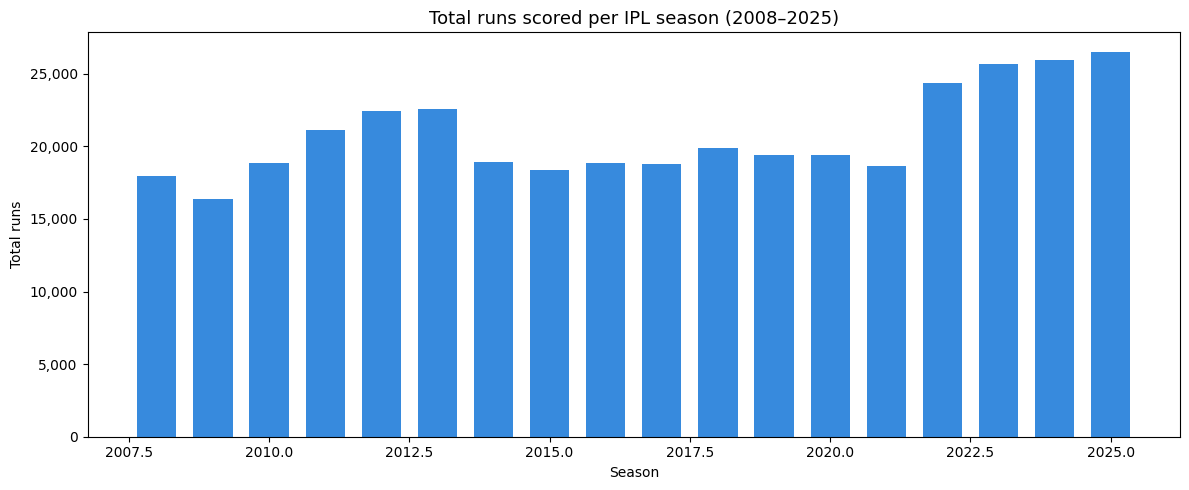

Chart 1 saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Create the charts folder
os.makedirs('charts', exist_ok=True)

#  Chart 1: Total runs per season ---
season_runs = (
    df.groupby('season_year')['total_runs']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(season_runs['season_year'], season_runs['total_runs'],
       color='#378ADD', edgecolor='none', width=0.7)
ax.set_title('Total runs scored per IPL season (2008–2025)', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('Total runs')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.tight_layout()
plt.savefig('charts/01_runs_per_season.png', dpi=150)
plt.show()
print("Chart 1 saved.")


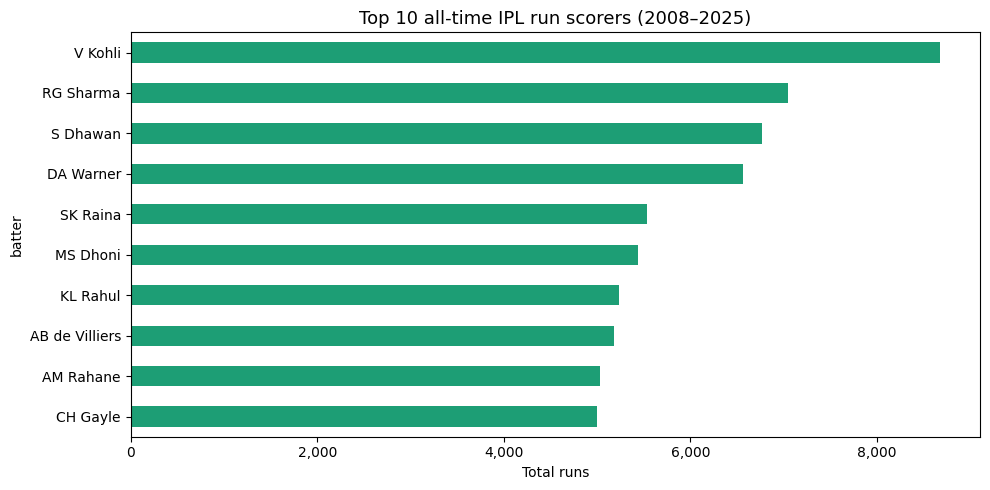

Chart 2 saved.


In [ ]:
#  Chart 2: Top 10 run scorers (all time) 
top_batters = (
    df.groupby('batter')['batter_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()  # Sort ascending so the bar chart reads top-to-bottom
)

fig, ax = plt.subplots(figsize=(10, 5))
top_batters.plot(kind='barh', ax=ax, color='#1D9E75', edgecolor='none')
ax.set_title('Top 10 all-time IPL run scorers (2008–2025)', fontsize=13)
ax.set_xlabel('Total runs')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.tight_layout()
plt.savefig('charts/02_top_batters.png', dpi=150)
plt.show()
print("Chart 2 saved.")


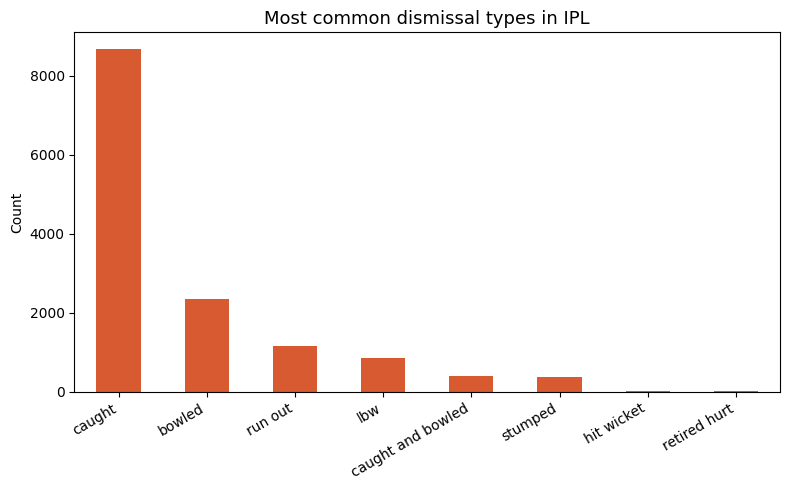

Chart 3 saved.


In [ ]:
#  Chart 3: Dismissal types breakdown 
dismissals = (
    df[df['is_wicket'] == 1]['dismissal_type']
    .value_counts()
    .head(8)
)

fig, ax = plt.subplots(figsize=(8, 5))
dismissals.plot(kind='bar', ax=ax, color='#D85A30', edgecolor='none')
ax.set_title('Most common dismissal types in IPL', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('charts/03_dismissals.png', dpi=150)
plt.show()
print("Chart 3 saved.")

In [ ]:
# It creates a per-season batter summary for Excel

os.makedirs('excel', exist_ok=True)

batter_summary = df.groupby(['batter', 'season_year', 'batting_team']).agg(
    total_runs    = ('batter_runs',  'sum'),
    balls_faced   = ('valid_ball',    'sum'),
    fours         = ('is_four',       'sum'),
    sixes         = ('is_six',        'sum'),
    wickets       = ('is_wicket',     'sum'),
    matches       = ('match_id',      'nunique')
).reset_index()

# Calculate strike rate — runs per 100 balls
batter_summary['strike_rate'] = (
    batter_summary['total_runs'] /
    batter_summary['balls_faced'].replace(0, np.nan) * 100
).round(2)

# Calculate batting average — runs per wicket
batter_summary['average'] = (
    batter_summary['total_runs'] /
    batter_summary['wickets'].replace(0, np.nan)
).round(2)

# Export to Excel
batter_summary.to_excel('excel/batter_summary.xlsx', index=False)

print("Excel file exported.") 

Excel file exported.
